In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [9]:
df= pd.read_csv('/content/Titanic-Dataset.csv')

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.shape

(891, 12)

In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Gender,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
## filling missing values

df["Age"]= df["Age"].fillna(df["Age"].mean())
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode())

In [14]:
df["has_cabin"]= df["Cabin"].notnull().astype(int)

In [15]:
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,has_cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [16]:
 df =df.drop(["PassengerId","Name","Ticket","Cabin"], axis= 1)
df.head()

,Survived,Pclass,Gender,Age,SibSp,Parch,Fare,Embarked,has_cabin
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0


In [17]:
df['Survived'].value_counts(normalize= True)* 100

,proportion
Survived,
0,61.616162
1,38.383838


In [18]:
df.groupby('Gender')['Survived'].value_counts(normalize= True)* 100

Gender  Survived
female  1           74.203822
        0           25.796178
male    0           81.109185
        1           18.890815
Name: proportion, dtype: float64

<Axes: xlabel='Survived', ylabel='count'>

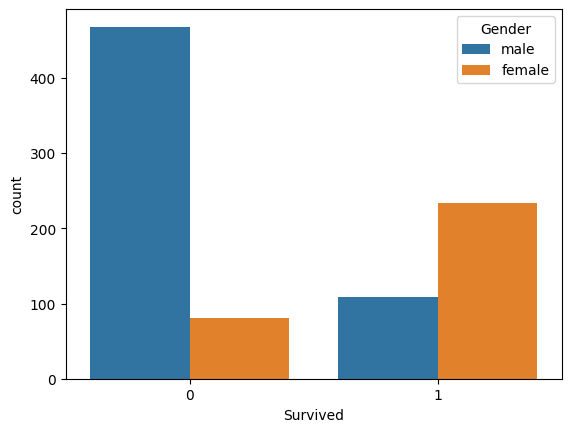

In [19]:
sns.countplot(x= 'Survived', hue='Gender', data= df)

<Axes: xlabel='Pclass', ylabel='Survived'>

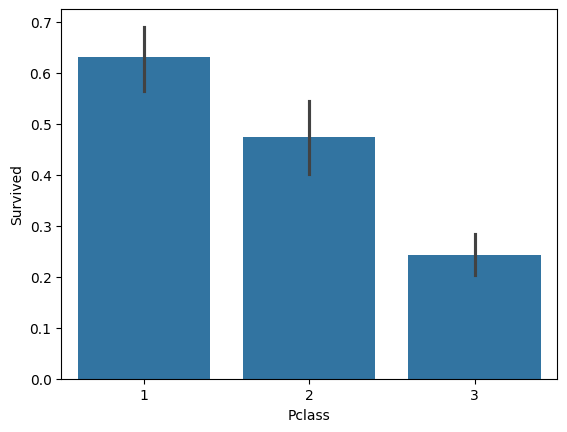

In [20]:
sns.barplot(x='Pclass', y='Survived', data=df)

<Axes: xlabel='has_cabin', ylabel='Survived'>

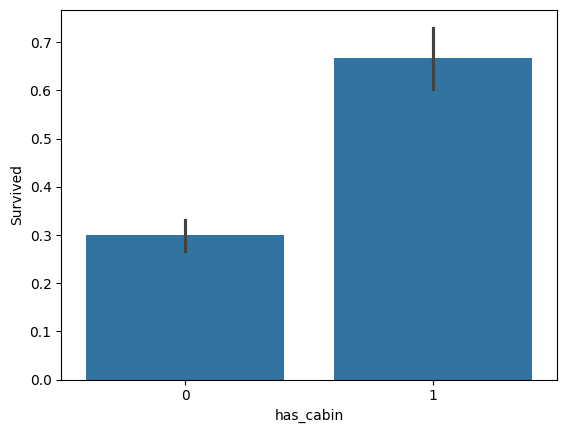

In [21]:
sns.barplot(x='has_cabin', y='Survived', data=df)

<Axes: >

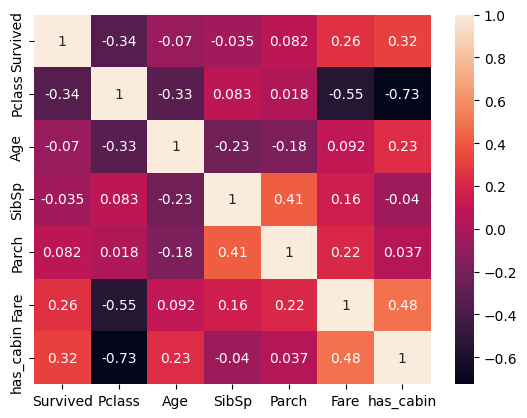

In [22]:
corr= df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

In [23]:
new_df = df[[	"Survived","Pclass","Gender","Age","Fare","Embarked"	,"has_cabin"]]

In [24]:
new_df.head()

,Survived,Pclass,Gender,Age,Fare,Embarked,has_cabin
0,0,3,male,22.0,7.2500,S,0
1,1,1,female,38.0,71.2833,C,1
2,1,3,female,26.0,7.9250,S,0
3,1,1,female,35.0,53.1000,S,1
4,0,3,male,35.0,8.0500,S,0


In [25]:
## label encoding

from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
new_df["Gender"]= le.fit_transform(new_df["Gender"])
new_df["Embarked"]=le.fit_transform(new_df["Embarked"])

In [26]:
new_df.head()

,Survived,Pclass,Gender,Age,Fare,Embarked,has_cabin
0,0,3,1,22.0,7.2500,2,0
1,1,1,0,38.0,71.2833,0,1
2,1,3,0,26.0,7.9250,2,0
3,1,1,0,35.0,53.1000,2,1
4,0,3,1,35.0,8.0500,2,0


In [27]:
new_df=pd.get_dummies(new_df, columns=["Pclass"])

In [28]:
## one hot encoding
new_df=new_df.astype(int)
new_df.head()

,Survived,Gender,Age,Fare,Embarked,has_cabin,Pclass_1,Pclass_2,Pclass_3
0,0,1,22,7,2,0,0,0,1
1,1,0,38,71,0,1,1,0,0
2,1,0,26,7,2,0,0,0,1
3,1,0,35,53,2,1,1,0,0
4,0,1,35,8,2,0,0,0,1


In [29]:
## standardlization

from sklearn.preprocessing import StandardScaler
ss= StandardScaler()
new_df["Age"]= ss.fit_transform(new_df[["Age"]])
new_df["Fare"]= ss.fit_transform(new_df[["Fare"]])

In [30]:
new_df.head()

,Survived,Gender,Age,Fare,Embarked,has_cabin,Pclass_1,Pclass_2,Pclass_3
0,0,1,-0.580044,-0.498948,2,0,0,0,1
1,1,0,0.650112,0.789405,0,1,1,0,0
2,1,0,-0.272505,-0.498948,2,0,0,0,1
3,1,0,0.419458,0.427056,2,1,1,0,0
4,0,1,0.419458,-0.478817,2,0,0,0,1


In [31]:
## logistic regression

In [32]:
from sklearn.model_selection import train_test_split
x= new_df.drop("Survived", axis=1)
y= new_df["Survived"]

In [33]:
X_train, X_test, y_train, y_test= train_test_split(x,y, test_size= 0.2, random_state=42)

In [34]:
from sklearn.linear_model import LogisticRegression

model_log= LogisticRegression()

In [35]:
model_log.fit(X_train, y_train)

LogisticRegression()

In [36]:
y_pred=model_log.predict(X_test)

In [37]:
y_test

,Survived
709,1
439,0
840,0
720,1
39,1
...,...
433,0
773,0
25,1
84,1


In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [39]:
print(accuracy_score(y_test, y_pred))

0.8044692737430168


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [41]:
confusion_matrix(y_test, y_pred)

array([[89, 16],
       [19, 55]])

knn: k nearest neighbours/k neighbours classifier

In [42]:
from sklearn.neighbors import KNeighborsClassifier

In [43]:
modal_knn= KNeighborsClassifier(n_neighbors=7)

In [44]:
modal_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [45]:
y_yred_knn=modal_knn.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [47]:
print(accuracy_score(y_test, y_yred_knn))

0.8212290502793296


In [48]:
print(classification_report(y_test, y_yred_knn))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84       105
           1       0.76      0.82      0.79        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



In [49]:
print(confusion_matrix(y_test, y_yred_knn))

[[86 19]
 [13 61]]


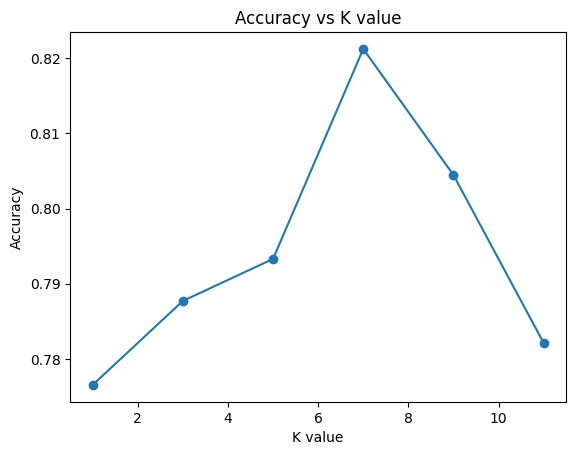

In [50]:

k_values = range(1, 12, 2)
accuracy_scores = []

for k in k_values:
    model_knn = KNeighborsClassifier(n_neighbors=k)
    model_knn.fit(X_train, y_train)
    y_pred_knn = model_knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_knn)
    accuracy_scores.append(accuracy)

plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K value')
plt.show()

In [51]:
accuracy_scores

[0.776536312849162,
 0.7877094972067039,
 0.7932960893854749,
 0.8212290502793296,
 0.8044692737430168,
 0.7821229050279329]

In [52]:
X_train.shape

(712, 8)

## naive bayes

In [53]:
from sklearn.naive_bayes import GaussianNB

In [54]:
modal_nb=GaussianNB()

In [55]:
modal_nb.fit(X_train, y_train)

GaussianNB()

In [56]:
y_pred_nb=modal_nb.predict(X_test)

In [57]:
print(accuracy_score(y_test, y_pred_nb))

0.7541899441340782


In [58]:
print(confusion_matrix(y_test, y_pred_nb))

[[84 21]
 [23 51]]


In [59]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.79      0.80      0.79       105
           1       0.71      0.69      0.70        74

    accuracy                           0.75       179
   macro avg       0.75      0.74      0.75       179
weighted avg       0.75      0.75      0.75       179



## Decision tree

In [60]:
from sklearn.tree import DecisionTreeClassifier

In [61]:
modal_dc= DecisionTreeClassifier()

In [62]:
modal_dc.fit(X_train, y_train)

DecisionTreeClassifier()

In [63]:
modal_dc.predict(X_test)

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1])

In [64]:
y_pred_dc=modal_dc.predict(X_test)

In [65]:
print(accuracy_score(y_test, y_pred_dc))

0.8100558659217877


In [66]:
print(confusion_matrix(y_test, y_pred_dc))

[[91 14]
 [20 54]]


In [67]:
print(classification_report(y_test, y_pred_dc))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

